In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from PIL import Image
import os

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

In [2]:
df = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\02-Generate Standard Smile\Valid_12756.csv")

In [3]:
df['Label'].value_counts()

Label
0    6645
1    6111
Name: count, dtype: int64

In [4]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","nHBDon","nHBAcc"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [5]:
df_lipinski = lipinski(df.Smiles)

In [6]:
df_lipinski['MW_scaled'] = df_lipinski['MW'] * 0.01

In [7]:
df_lipinski

,MW,LogP,nHBDon,nHBAcc,MW_scaled
0,1163.598,3.67500,10.0,13.0,11.63598
1,1145.583,4.48020,9.0,12.0,11.45583
2,179.606,2.59380,1.0,2.0,1.79606
3,305.502,3.19840,1.0,2.0,3.05502
4,368.868,3.58060,2.0,3.0,3.68868
...,...,...,...,...,...
12751,355.777,3.73940,1.0,5.0,3.55777
12752,643.535,4.50730,2.0,11.0,6.43535
12753,578.614,3.46124,4.0,10.0,5.78614
12754,431.470,2.35910,2.0,7.0,4.31470


In [14]:
features = ['MW','MW_scaled','LogP','nHBDon','nHBAcc']
stats = df_lipinski[features].agg(['mean','median','std','max','min'])
print(stats)
stats.to_csv(r"E:\Projects\Mycobacterium tuberculosis\02-Generate Standard Smile\stats.csv",index=False)

                 MW  MW_scaled       LogP     nHBDon     nHBAcc
mean     411.073028   4.110730   3.883034   1.328238   5.565851
median   392.249000   3.922490   3.882010   1.000000   5.000000
std      145.342261   1.453423   2.073390   1.578389   2.927822
max     2094.431000  20.944310  17.895600  22.000000  45.000000
min       45.085000   0.450850 -10.336900   0.000000   0.000000


In [8]:
df_melt = df_lipinski.melt(
    value_vars=['MW_scaled','LogP','nHBDon','nHBAcc'],
    var_name='Property',
    value_name='Value'
)
df_melt

,Property,Value
0,MW_scaled,11.63598
1,MW_scaled,11.45583
2,MW_scaled,1.79606
3,MW_scaled,3.05502
4,MW_scaled,3.68868
...,...,...
51019,nHBAcc,5.00000
51020,nHBAcc,11.00000
51021,nHBAcc,10.00000
51022,nHBAcc,7.00000


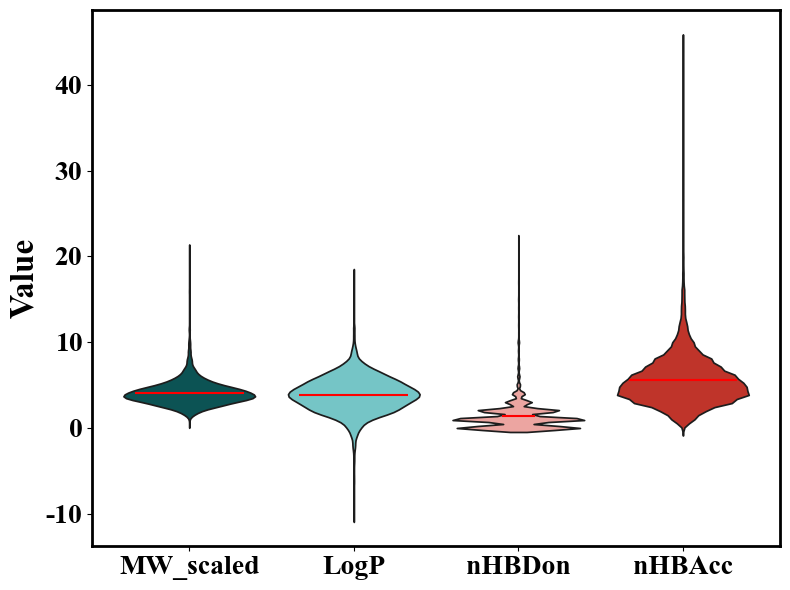

In [46]:
plot_order = ['MW_scaled', 'LogP', 'nHBDon', 'nHBAcc']

color_schemes = {0: ['#005f60', '#68d2d3', '#f89a94', '#d81e11']}
color_scheme = 0
selected_colors = color_schemes[color_scheme]
palette_colors = dict(zip(plot_order, selected_colors))

fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=df_melt,
    x='Property',
    y='Value',
    order=plot_order,
    hue='Property',
    palette=palette_colors,
    ax=ax,
    legend=False,
    inner=None
)

for i, prop in enumerate(plot_order):
    mean_val = df_melt[df_melt['Property']==prop]['Value'].mean()
    if i == 2:
        ax.hlines(mean_val, 
                  i-0.1, 
                  i+0.1, 
                  color='red', 
                  linewidth=1.5)
    else:
        ax.hlines(mean_val, 
                  i-0.33, 
                  i+0.33, 
                  color='red', 
                  linewidth=1.5)

ax.set_xlabel('')
ax.set_ylabel('Value', fontsize=24, fontweight='bold')

for spine in ax.spines.values():
    spine.set_linewidth(2)

for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

plt.tight_layout()

#plt.savefig("Lipinski.pdf", format='pdf', bbox_inches='tight')

plt.show()